# 03 Modeling
## 모델링

Basic vs transaction-added model comparison.


## Setup
### 설정


In [1]:
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")
os.environ.setdefault("PYTHONIOENCODING", "utf-8")
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from lightgbm import LGBMClassifier
except ImportError:
    LGBMClassifier = None

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid")
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120

candidate_processed_dirs = []
if os.environ.get("XENTE_PROCESSED_DIR"):
    candidate_processed_dirs.append(Path(os.environ["XENTE_PROCESSED_DIR"]))
candidate_processed_dirs.extend([
    Path.cwd().parent / "outputs" / "tables",
    Path.cwd() / "outputs" / "tables",
    Path.cwd().parent / "processed",
    Path.cwd() / "processed",
    Path("/content/drive/MyDrive/XENTE DATA/processed"),
])
PROCESSED_DIR = next(
    (path for path in candidate_processed_dirs if (path / "train_model_table_v1.csv").exists()),
    candidate_processed_dirs[0],
)
OUTPUT_DIR = PROCESSED_DIR / "modeling_validation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
model_table = pd.read_csv(PROCESSED_DIR / "train_model_table_v1.csv")
model_table["IsDefaulted"] = model_table["IsDefaulted"].astype(int)
cold_start = model_table[
    model_table["repayment_history_segment"].eq("cold_start_no_known_repayment")
].copy()

display(pd.DataFrame([{
    "segment": "cold_start_no_known_repayment",
    "rows": len(cold_start),
    "defaults": int(cold_start["IsDefaulted"].sum()),
}]))


,segment,rows,defaults
0,cold_start_no_known_repayment,385,59


## Feature sets
### 변수 세트


In [3]:
target_col = "IsDefaulted"
group_col = "CustomerId"

basic_features = [
    "ProductCategory", "InvestorId", "SubscriptionId", "current_value_log",
    "issue_month", "issue_weekday",
]
transaction_features = [
    "has_prior_txn", "prior_txn_count_all", "prior_txn_active_days_all",
    "prior_txn_recency_days_all", "prior_txn_amount_mean_all",
    "prior_txn_amount_std_all", "prior_provider_nunique_all",
    "prior_product_category_nunique_all",
]
product_removed_basic = [
    "SubscriptionId", "current_value_log", "issue_month", "issue_weekday",
]
behavior_only_basic = [
    "SubscriptionId", "issue_month", "issue_weekday",
]

feature_specs = [
    {
        "track": "A_operational",
        "base_feature_set": "A0_Basic",
        "new_feature_set": "A2_Basic_Transaction",
        "base_features": basic_features,
        "new_features": basic_features + transaction_features,
    },
    {
        "track": "B_product_operation_removed",
        "base_feature_set": "B0_Basic",
        "new_feature_set": "B2_Basic_Transaction",
        "base_features": product_removed_basic,
        "new_features": product_removed_basic + transaction_features,
    },
    {
        "track": "C_behavior_only_validation",
        "base_feature_set": "C0_Basic",
        "new_feature_set": "C2_Basic_Transaction",
        "base_features": behavior_only_basic,
        "new_features": behavior_only_basic + transaction_features,
    },
]

for spec in feature_specs:
    spec["base_features"] = [feature for feature in spec["base_features"] if feature in cold_start.columns]
    spec["new_features"] = [feature for feature in spec["new_features"] if feature in cold_start.columns]


## Validation functions
### 검증 함수


In [4]:
def top_capture_rate(y_true, y_score, top_fraction=0.10):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    cutoff = max(1, int(np.ceil(len(y_true) * top_fraction)))
    top_index = np.argsort(-y_score)[:cutoff]
    total_defaults = y_true.sum()
    if total_defaults == 0:
        return np.nan
    return y_true[top_index].sum() / total_defaults


def build_preprocessor(data, features):
    categorical_features = [
        feature for feature in features
        if data[feature].dtype == "object" or str(data[feature].dtype).startswith("category")
    ]
    numeric_features = [feature for feature in features if feature not in categorical_features]

    return ColumnTransformer(
        transformers=[
            ("numeric", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), numeric_features),
            ("categorical", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]), categorical_features),
        ],
        remainder="drop",
    )


def make_model(model_kind, data, features):
    preprocessor = build_preprocessor(data, features)
    if model_kind == "LR-WOE":
        estimator = LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear")
    elif model_kind == "LightGBM":
        if LGBMClassifier is None:
            raise ImportError("lightgbm is not installed. Install requirements.txt or skip LightGBM.")
        estimator = LGBMClassifier(
            n_estimators=200,
            learning_rate=0.03,
            num_leaves=15,
            min_child_samples=20,
            class_weight="balanced",
            random_state=42,
            verbose=-1,
        )
    else:
        raise ValueError(model_kind)
    return Pipeline([("preprocess", preprocessor), ("model", estimator)])


def run_oof_validation(data, features, model_kind, n_splits=5):
    x = data[features].copy()
    y = data[target_col].astype(int).values
    groups = data[group_col].astype(str).values
    splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = np.zeros(len(data))

    for train_idx, valid_idx in splitter.split(x, y, groups):
        model = make_model(model_kind, data.iloc[train_idx], features)
        model.fit(x.iloc[train_idx], y[train_idx])
        scores[valid_idx] = model.predict_proba(x.iloc[valid_idx])[:, 1]

    return {
        "PR_AUC": average_precision_score(y, scores),
        "Top10_Capture": top_capture_rate(y, scores, top_fraction=0.10),
        "scores": scores,
    }


## OOF model comparison
### OOF 모델 비교


In [5]:
result_rows = []
score_frames = []

model_kinds = ["LR-WOE"] + (["LightGBM"] if LGBMClassifier is not None else [])

for spec in feature_specs:
    for model_kind in model_kinds:
        base_result = run_oof_validation(cold_start, spec["base_features"], model_kind)
        new_result = run_oof_validation(cold_start, spec["new_features"], model_kind)

        result_rows.append({
            "track": spec["track"],
            "model_kind": model_kind,
            "base_feature_set": spec["base_feature_set"],
            "new_feature_set": spec["new_feature_set"],
            "base_PR_AUC": base_result["PR_AUC"],
            "new_PR_AUC": new_result["PR_AUC"],
            "delta_PR_AUC": new_result["PR_AUC"] - base_result["PR_AUC"],
            "base_Top10_Capture": base_result["Top10_Capture"],
            "new_Top10_Capture": new_result["Top10_Capture"],
            "delta_Top10_Capture": new_result["Top10_Capture"] - base_result["Top10_Capture"],
        })

        for label, scores in [
            (spec["base_feature_set"], base_result["scores"]),
            (spec["new_feature_set"], new_result["scores"]),
        ]:
            temp = cold_start[[target_col]].copy()
            temp["score"] = scores
            temp["prediction_col"] = f"{spec['track']}__{label}__{model_kind}"
            temp["score_band"] = pd.qcut(
                temp["score"].rank(method="first", ascending=False),
                q=5,
                labels=[f"Band {i}" for i in range(1, 6)],
            )
            score_frames.append(temp)

delta_results = pd.DataFrame(result_rows)
display(delta_results)
delta_results.to_csv(OUTPUT_DIR / "cold_start_transaction_incremental_value_delta.csv", index=False)


,track,model_kind,base_feature_set,new_feature_set,base_PR_AUC,new_PR_AUC,delta_PR_AUC,base_Top10_Capture,new_Top10_Capture,delta_Top10_Capture
0,A_operational,LR-WOE,A0_Basic,A2_Basic_Transaction,0.719389,0.692569,-0.026820,0.525424,0.525424,0.000000
1,A_operational,LightGBM,A0_Basic,A2_Basic_Transaction,0.668150,0.681224,0.013074,0.491525,0.508475,0.016949
2,B_product_operation_removed,LR-WOE,B0_Basic,B2_Basic_Transaction,0.717890,0.695615,-0.022275,0.525424,0.525424,0.000000
3,B_product_operation_removed,LightGBM,B0_Basic,B2_Basic_Transaction,0.660613,0.687537,0.026924,0.491525,0.508475,0.016949
4,C_behavior_only_validation,LR-WOE,C0_Basic,C2_Basic_Transaction,0.700252,0.708068,0.007816,0.525424,0.525424,0.000000
5,C_behavior_only_validation,LightGBM,C0_Basic,C2_Basic_Transaction,0.647855,0.664273,0.016418,0.508475,0.508475,0.000000


## Score bands
### 점수 구간


In [6]:
score_band_rows = []
for score_data in score_frames:
    prediction_col = score_data["prediction_col"].iloc[0]
    for band, sub in score_data.groupby("score_band", observed=False):
        score_band_rows.append({
            "prediction_col": prediction_col,
            "score_band": str(band),
            "count": len(sub),
            "default_count": int(sub[target_col].sum()),
            "default_rate": sub[target_col].mean(),
            "capture_rate": sub[target_col].sum() / cold_start[target_col].sum(),
        })

score_band_results = pd.DataFrame(score_band_rows)
score_band_results["default_rate_pct"] = score_band_results["default_rate"] * 100
score_band_results["capture_rate_pct"] = score_band_results["capture_rate"] * 100
display(score_band_results.head(20))
score_band_results.to_csv(OUTPUT_DIR / "cold_start_score_band_all.csv", index=False)


,prediction_col,score_band,count,default_count,default_rate,capture_rate,default_rate_pct,capture_rate_pct
0,A_operational__A0_Basic__LR-WOE,Band 1,77,50,0.649351,0.847458,64.935065,84.745763
1,A_operational__A0_Basic__LR-WOE,Band 2,77,2,0.025974,0.033898,2.597403,3.389831
2,A_operational__A0_Basic__LR-WOE,Band 3,77,4,0.051948,0.067797,5.194805,6.779661
3,A_operational__A0_Basic__LR-WOE,Band 4,77,3,0.038961,0.050847,3.896104,5.084746
4,A_operational__A0_Basic__LR-WOE,Band 5,77,0,0.000000,0.000000,0.000000,0.000000
5,A_operational__A2_Basic_Transaction__LR-WOE,Band 1,77,50,0.649351,0.847458,64.935065,84.745763
6,A_operational__A2_Basic_Transaction__LR-WOE,Band 2,77,2,0.025974,0.033898,2.597403,3.389831
7,A_operational__A2_Basic_Transaction__LR-WOE,Band 3,77,5,0.064935,0.084746,6.493506,8.474576
8,A_operational__A2_Basic_Transaction__LR-WOE,Band 4,77,2,0.025974,0.033898,2.597403,3.389831
9,A_operational__A2_Basic_Transaction__LR-WOE,Band 5,77,0,0.000000,0.000000,0.000000,0.000000


## Performance delta plot
### 성능 변화 그림


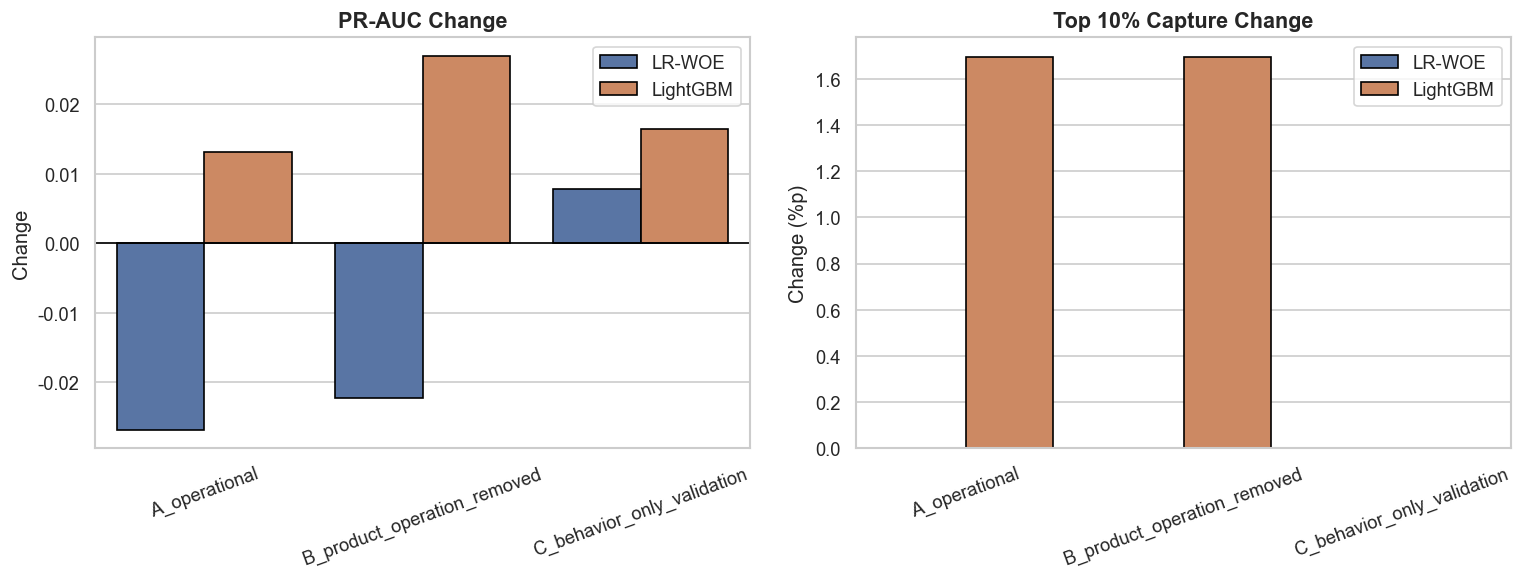

In [7]:
plot_delta = delta_results.copy()
plot_delta["delta_Top10_Capture_pctp"] = plot_delta["delta_Top10_Capture"] * 100

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.0))
for ax, y_col, title, y_label in [
    (axes[0], "delta_PR_AUC", "PR-AUC Change", "Change"),
    (axes[1], "delta_Top10_Capture_pctp", "Top 10% Capture Change", "Change (%p)"),
]:
    sns.barplot(
        data=plot_delta,
        x="track",
        y=y_col,
        hue="model_kind",
        edgecolor="black",
        linewidth=1,
        ax=ax,
    )
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(y_label)
    ax.tick_params(axis="x", rotation=20)
    ax.legend(title="")
plt.tight_layout()
plt.show()
